Data Exploration (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes.csv")  # e.g., Titanic dataset
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
# Basic info
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

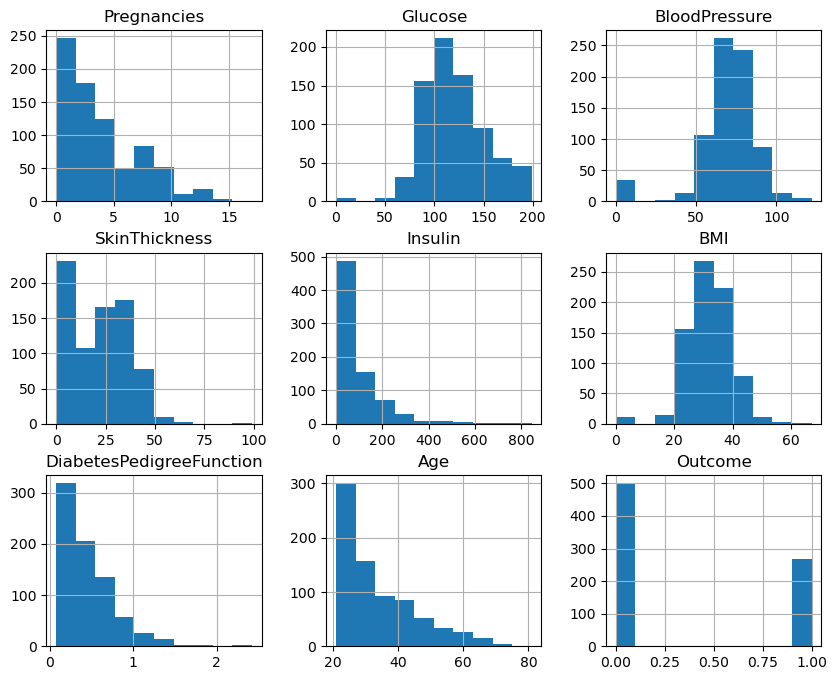

In [5]:
# Histogram
df.hist(figsize=(10,8))
plt.show()

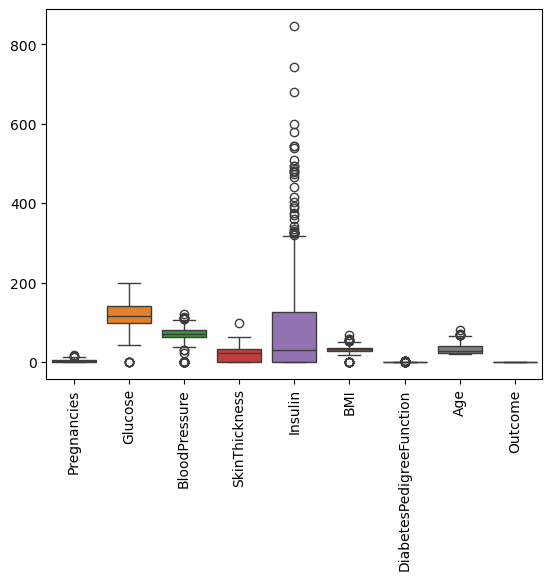

In [9]:
# Boxplot (for outliers)
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

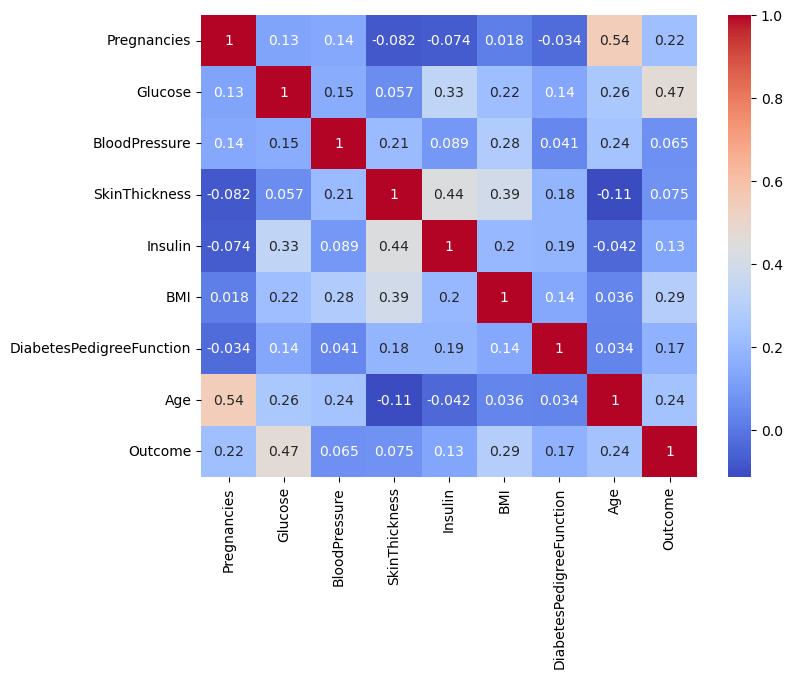

In [10]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Data Preprocessing

In [11]:
# Replace 0 with NaN in important columns
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values with median
df.fillna(df.median(), inplace=True)

In [12]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Model Building

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Model Evaluation

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1 Score: 0.6415094339622641
ROC-AUC: 0.8229568411386594


ROC Curve

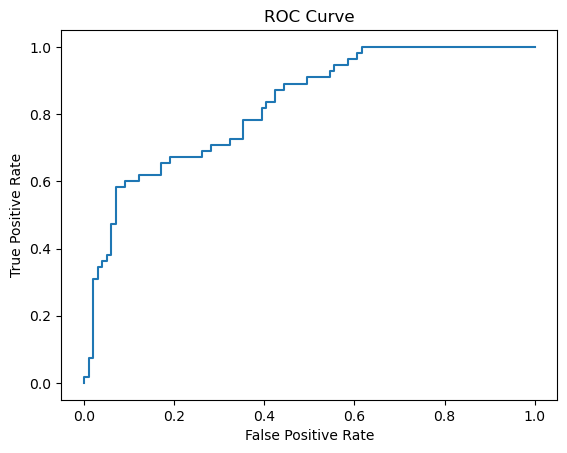

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Interpretation

In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                    Feature  Coefficient
1                   Glucose     1.114496
5                       BMI     0.683509
7                       Age     0.401210
0               Pregnancies     0.226785
6  DiabetesPedigreeFunction     0.200471
3             SkinThickness     0.071687
4                   Insulin    -0.135922
2             BloodPressure    -0.151407


In [17]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [18]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("Diabetes Prediction App")

# Inputs
preg = st.number_input("Pregnancies")
glucose = st.number_input("Glucose")
bp = st.number_input("Blood Pressure")
skin = st.number_input("Skin Thickness")
insulin = st.number_input("Insulin")
bmi = st.number_input("BMI")
dpf = st.number_input("Diabetes Pedigree Function")
age = st.number_input("Age")

# Prediction
if st.button("Predict"):
    data = np.array([[preg, glucose, bp, skin, insulin, bmi, dpf, age]])
    data_scaled = scaler.transform(data)
    result = model.predict(data_scaled)

    if result[0] == 1:
        st.error("Diabetic")
    else:
        st.success("Not Diabetic")

2026-04-24 17:55:26.029 
  command:

    streamlit run C:\Users\DELL\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-24 17:55:26.036 Session state does not function when running a script without `streamlit run`


In [ ]:
INTERVIEW QUESTIONS (IMPORTANT)
1. Precision vs Recall

Answer:

“Precision measures how many predicted positives are actually correct, while recall measures how many actual positives were correctly identified.”

Precision → avoid false positives
Recall → avoid missing real cases

2. Cross Validation

Answer:

“Cross-validation is a technique where the dataset is split into multiple folds, and the model is trained and tested multiple times to ensure stability and avoid overfitting.”